# Class XX: Hypergraph Models
Goal of today's class:

1. Define hypergraph and learn some hypergraph properties
3. Compare graphs, hypergraphs, and simplicial complexes
4. Investigate some hypergraph models 
5. Build a hypergraph model using data 

*Acknowledgement: This chapter relies on \_\_\_\_\_\_\_\_\_\_ from \_\_\_\_\_\_\_\_\_\_.*
__________

# Table of Contents
1. [Introduction to hypergraphs](#Intro)
2. [Hypergraph Analysis using Python](#Python)
3. [Graphs vs. Hypergraphs vs. Simplicial Complexes](#Comparison)
4. [Hypergraph Models](#Models)


________
## 1. Introduction to hypergraphs

In this course, we have extensively studied the mathematical object $G= \langle V, E\rangle$, also called a graph, consisting of a set of nodes $V$ and set of edges $E$. Two nodes $i$ and $j$ are said to be connected if and only if $(i, j) \in E$. In this context, $E$ is a set of pairs describing the connectivity structure of the graph. A *hypergraph* generalizes this notion by allowing an edge to connect any number of vertices, not just two. 

Formally, a *hypergraph* $H$ is a pair $\langle V, E\rangle$ where $E = (e_i)_{i \in I}$ and $V$ is a finite set of nodes. An element $e \in E$ is called a *hyperedge*. 

![Graph vs Hypergraph](images/hypergraph_ex.jpg)

As shown above, we have a graph, G (left) and a hypergraph H (right) on the same node set $V= \{1, 2, 3, 4\}$

*What observations can you make on the differences/similarities between these two objects? What are the hyperedges of graph $H$?*

. We make some observations: 
* Observation 1: The edge set of $G$ is $E = \{(1, 2), (2, 3), (3, 4), (2, 4)\}$
* Observation 2: The edge set of $H$ is $E = \{(1, 2, 3), (2, 4), (1, 3, 4), (1, 4)\}$
* Observation 3: The edges $(1, 2)$ and $(2, 3)$  are incident to each other in graph $G$. 
* Observation 4: The hyperedge $(1, 4)$ is a subset of hyperedge $(1, 3, 4)$ in $H$. 
* Observation 5: Hyperedges intersect (i.e. $(1, 4)$ and $(2, 4)$)


The first observation highlights the stricter relational structure imposed by the graph $G$. In a traditional graph, an edge can connect only two vertices, meaning that $G$ can represent only pairwise interactions. As a result, any higher-order, polyadic relationships present in the hypergraph $H$ are ``compressed'' or lost when viewed through $G$. In contrast, $H$ contains hyperedges that may include more than two nodes (Observation 2). For example, the hyperedges $(1,2,3)$ and $(1,3,4)$ each capture a three-way relationship among their vertices.

A further distinction is that hyperedges can intersect in multiple vertices (as in Observation 5). For instance, $(1,2,3)$ and $(1,3,4)$ intersect in the set $\{1,3\}$. Hyperedges can even be fully nested within one another (Observation 4). These behaviors differ from ordinary graphs, where edges may meet only at a single shared endpoint and cannot overlap in richer ways.



______
### The usefulness of hypergraphs
*Brainstorm*: What sorts of applications in network science do you think neccitates the use of hypergraphs over traditional graphs? 

The introduction of polyadic connections in the hypergraph setting brings light to an entire new class of research questions. Now researchers are asking questions like

* What complex structures have higher-order interactions and how do we best model them? [10]
* Which sets of nodes must act together for a process to occur? [11]
* What is the distribution of hyperedge sizes? What are motifs in the hypergraph?[17]
* How does higher-order structure change centrality? [18], [19]
* Which contagion events require simultaneous exposure from multiple neighbors? [11]

Therefore, hypergraphs can be used to represent structures like co-authorship [20], social networks [15], biological systems [12], [13], [14], and more [16].

Before coming up with our own research questions, let's go over some ways to represent the connectivity of a hypergraph using matrices.

________
### Hypergraph Matrix Representations

Graph edges connect pairs of vertices. The connectivity structure of graphs are easily represented via the adjacency matrix $A$, where $a_{ij} = 1$ if $i$-th and $j$-th vertices are connected, otherwise $a_{ij} = 0$. This concept of adjacency must be extended to fit the structure of a hypergraph. 

*Definition*: Two nodes are said to be *e-adjacent* if they belong to any common hyperedge. 

*Defintion*: Two nodes are said to be $k$-*adjacent* if they appear together in a hyperedge with $k$ nodes. 

Which nodes are 2-adjacent in the example hypergraph below? 3-adjacent?

#### Incident Matrix
Let $H = (V, E)$ be a hypergraph where 
$V = \{v_1, \dots, v_n\}$ is the set of vertices and 
$E = \{e_1, \dots, e_m\}$ is the set of hyperedges with each 
$e_j \subseteq V$.  

The *incidence matrix* of $H$ is the $n \times m$ matrix 
$J$ defined by


$$J_{ij} = 
\begin{cases}
1 \text{ if } v_i \in e_j, \\
0 \text{ otherwise}.
\end{cases}
$$

Thus, column $j$ of $J$ encodes the membership of vertices in the hyperedge $e_j$.



In our example hypergraph, the incidence matrix is the $4\times4$ matrix: 

$$J = 
\begin{pmatrix}
1 & 0 & 1 & 1\\
1 & 1 & 0 & 0 \\
1 & 1 & 0 & 1 \\
1 & 1 & 1 & 0
\end{pmatrix}
$$

Notice how each $(i,j)$-th entry tells us whether node $i$ is contained in edge $j$:
$$\begin{array}{c|cccc}
 & e_1 & e_2 & e_3 & e_4 \\ \hline
v_1 & 1 & 0 & 1 & 1 \\
v_2 & 1 & 1 & 0 & 0 \\
v_3 & 1 & 1 & 0 & 1 \\
v_4 & 1 & 1 & 1 & 0
\end{array}$$


#### Unweighted adjacency matrix 

Let $H = (V,E)$ be a hypergraph and let $J$ be its incidence matrix. Define the co-occurrence matrix  

$$C = J J^\top ,$$

so that $C_{ij}$ equals the number of hyperedges that contain both nodes $i$ and $j$.

The unweighted adjacency matrix $A$ is defined as  

$$A_{ij} = 
\begin{cases}
1, & i \neq j \ \text{and} \ C_{ij} \ge 1,\\[4pt]
0, & \text{otherwise}.
\end{cases}$$


In our example hypergraph, the unweighted adjacency matrix is the 

$$A = 
\begin{pmatrix}
0 & 1 & 1 & 1 \\
1 & 0 & 1 & 1 \\
1 & 1 & 0 & 1 \\
1 & 1 & 1 & 0
\end{pmatrix}
$$

Notice how each $(i,j)$-th entry tells whether nodes $i$ and $ $j$ share a hyperedge: 

$$\begin{array}{c|cccc}
     & v_1 & v_2 & v_3 & v_4 \\ \hline
v_1  & 0 & 1 & 1 & 1 \\
v_2  & 1 & 0 & 1 & 1 \\
v_3  & 1 & 1 & 0 & 1 \\
v_4  & 1 & 1 & 1 & 0
\end{array}$$

#### Weighted adjacency matrix

Using the same co-occurrence matrix $C = J J^{\top}$,  
the weighted adjacency matrix $A$ is defined as  

$$A_{ij} =
\begin{cases}
C_{ij}, & i \neq j \ \text{and} \ C_{ij} \ge 1,\\[4pt]
0, & \text{otherwise}.
\end{cases}$$

Thus, $A_{ij}$ equals the number of hyperedges that contain both nodes $i$ and $j$.


In our example hypergrap, the weighted adjacency matrix is the $4\times 4$ matrix:


$$A = 
\begin{pmatrix}
0 & 1 & 2 & 2 \\
1 & 0 & 1 & 1 \\
2 & 1 & 0 & 1 \\
2 & 1 & 1 & 0
\end{pmatrix}
$$

Notice how each $(i,j)$-th entry tells how many hyperedges node $i$ and node $j$ have in common: 

$$\begin{array}{c|cccc}
     & v_1 & v_2 & v_3 & v_4 \\ \hline
v_1  & 0 & 1 & 2 & 2 \\
v_2  & 1 & 0 & 1 & 1 \\
v_3  & 2 & 1 & 0 & 1 \\
v_4  & 2 & 1 & 1 & 0
\end{array}$$

#### Adjacency Tensor


Let $H=(V,E)$ be a hypergraph with $V=\{v_1,\dots,v_n\}$ and $E=\{e_1,\dots,e_m\}$.  The *adjacency tensor* of $H$ is the order-3 tensor  $\mathcal{A} \in \{0,1\}^{n \times n \times m}$ defined by

$$\mathcal{A}_{i j k} =
\begin{cases}
1 & \text{if } \{v_i,v_j\}\subseteq e_k,\; i\neq j,\\[6pt]
0 & \text{otherwise}.
\end{cases}$$

Each slice $\mathcal{A}[:,:,k]$ encodes the pairwise adjacency of the nodes contained in hyperedge $e_k$. We plot a visual for each slice below:


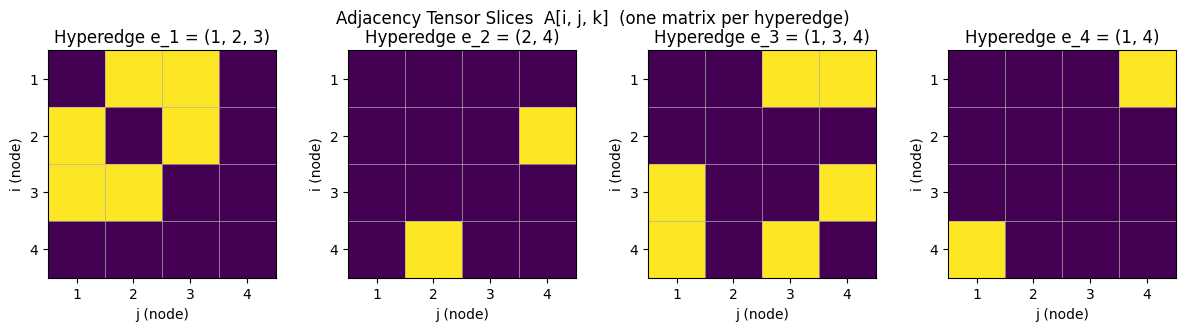

In [249]:
import numpy as np
import matplotlib.pyplot as plt


# Hypergraph edges from example above
hyperedges = [[0, 1, 2],  [1, 3],  [0, 2, 3], [0, 3] ]

num_nodes = 4
num_edges = len(hyperedges)

# Build the adjacency tensor A[i, j, k] 
A = np.zeros((num_nodes, num_nodes, num_edges), dtype=int)

for k, edge in enumerate(hyperedges):
    for i in edge:
        for j in edge:
            if i != j:
                A[i, j, k] = 1

# Plot each slice A[:, :, k] as an adjacency matrix 
fig, axes = plt.subplots(1, num_edges, figsize=(3 * num_edges, 3), constrained_layout=True)


for k in range(len(hyperedges)):
    ax = axes[k]
    im = ax.imshow(A[:, :, k], vmin=0, vmax=1)

    ax.set_xticks(range(num_nodes))
    ax.set_yticks(range(num_nodes))
    ax.set_xticklabels(range(1, num_nodes + 1))
    ax.set_yticklabels(range(1, num_nodes + 1))
    ax.set_xlabel("j (node)")
    ax.set_ylabel("i (node)")

    # Only use edges[k] if it actually exists
    edge_k = hyperedges[k]
    ax.set_title(f"Hyperedge e_{k+1} = {tuple(n+1 for n in edge_k)}")

    ax.set_xticks(np.arange(-0.5, num_nodes, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, num_nodes, 1), minor=True)
    ax.grid(which="minor", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)


plt.suptitle("Adjacency Tensor Slices  A[i, j, k]  (one matrix per hyperedge)", y=1.05)
plt.show()


*Tip*: You can think of the adjacency tensor as compartementalization of the unweighted adjancency matrix, where a "compartment" is a hyperedge. If you look at all the yellow squares across all the slices of the adjacency tensor above and combine them into one matrix, you should get back the unweighted adjacency matrix.

________
## 2. Hypergraph Analysis Using Python

Let's use python to compute these matrix representations.

In [113]:
# Define hyperedges based on the example hypergraph
hyperedges = [[1, 2, 3], [2, 4], [1, 3, 4], [1, 4]]

In [ ]:

def hypergraph_incidence_matrix(edges, num_nodes=None):
    """
    Build the incidence matrix J (node × edge) for a hypergraph.

    Parameters
    ----------
    edges : list of lists
        Hyperedges, each represented as a list of node indices.

    num_nodes : int, optional
        Total number of nodes. If None, inferred from edges.

    Returns
    -------
    J : numpy.ndarray (num_nodes × num_edges)
        J[i, j] = 1 iff node (i+1) is in hyperedge j.
    """

    # Infer number of nodes 
    if num_nodes is None:
        num_nodes = max(max(e) for e in edges)

    num_edges = len(edges)

    # Initialize matrix
    J = np.zeros((num_nodes, num_edges), dtype=int)

    # Fill entries
    for j, edge in enumerate(edges):
        for node in edge:
            J[node - 1, j] = 1   

    return J


In [120]:
J = hypergraph_incidence_matrix(hyperedges)
print (J)

[[1 0 1 1]
 [1 1 0 0]
 [1 0 1 0]
 [0 1 1 1]]


Your turn! Create a function that takes in the set of hyperedges as an input and returns the weighted adjacency as the output. You may use the hypergraph_incidence_matrix in your function.

In [ ]:
### Your turn
def hypergraph_weighted_adjacency(edges):
    """
    Compute the weighted adjacency matrix of a hypergraph.

    A[i,j] = number of hyperedges that contain both nodes i and j.
    A[i,i] = 0 

    Parameters
    ----------
    edges : list of lists
        Hyperedges, each represented as a list of node indices.

    Returns
    -------
    A : numpy.ndarray
        An n x n unweighted adjacency matrix 
    """

    pass

In [127]:
# Solution
def hypergraph_weighted_adjacency(edges):
    """
    Compute the weighted adjacency matrix of a hypergraph.

    A[i,j] = number of hyperedges that contain both nodes i and j.
    A[i,i] = 0 

    Parameters
    ----------
    edges : list of lists
        Hyperedges, each represented as a list of node indices.

    Returns
    -------
    A : numpy.ndarray
        An n x n unweighted adjacency matrix 
    """

    # Create incidence matrix
    I = hypergraph_incidence_matrix(edges)

    # Co-occurrence matrix C = I I^T
    C = I @ I.T

    # Create copy for weighted adjacency
    A = C.copy()

    # Remove diagonal 
    np.fill_diagonal(A, 0)

    return A


In [128]:
A_weighted = hypergraph_weighted_adjacency(hyperedges)
print(A_weighted)

[[0 1 2 2]
 [1 0 1 1]
 [2 1 0 1]
 [2 1 1 0]]


Here are functions for the other matrix represenations:

In [129]:
def hypergraph_unweighted_adjacency(edges):
    """
    Compute the unweighted adjacency matrix of a hypergraph.

    A[i, j] = 1 if nodes i and j co-occur in at least one hyperedge.
    A[i, j] = 0 otherwise. Diagonal entries are set to zero.

    Parameters
    ----------
    edges : list of lists
        Hyperedges, each represented as a list of node indices.

    Returns
    -------
    A : numpy.ndarray
        An n x n unweighted adjacency matrix 
    """


    # Create incidence matrix
    I = hypergraph_incidence_matrix(edges)

    # Co-occurrence matrix C = I I^T
    C = I @ I.T

    # Convert to unweighted adjacency
    A = (C >= 1).astype(int)

    # Remove diagonal (XGI convention: no self-loops)
    np.fill_diagonal(A, 0)

    return A

In [131]:
A_unweighted = hypergraph_unweighted_adjacency(hyperedges)
print(A_unweighted)

[[0 1 1 1]
 [1 0 1 1]
 [1 1 0 1]
 [1 1 1 0]]


In [31]:

def hypergraph_adjacency_tensor(edges, num_nodes=None):
    """
    Build adjacency tensor A for a hypergraph.

    Parameters
    ----------
    edges : list of lists
        Hyperedges, where each hyperedge is a list of node indices.
    num_nodes : int, optional
        Number of nodes. If None, inferred from edges.

    Returns
    -------
    A : numpy.ndarray
        A tensor of shape (num_nodes, num_nodes, num_edges)
        where A[i, j, k] = 1 if nodes i and j both appear 
        in hyperedge k (i != j), otherwise 0.
    """

    # Infer number of nodes if needed
    if num_nodes is None:
        num_nodes = max(max(e) for e in edges) + 1

    num_edges = len(edges)

    # Initialize tensor
    A = np.zeros((num_nodes, num_nodes, num_edges), dtype=int)

    # Fill each hyperedge slice
    for k, edge in enumerate(edges):
        nodes = list(edge)
        for i in nodes:
            for j in nodes:
                if i != j:
                    A[i, j, k] = 1    # pairwise adjacency within hyperedge

    return A


In [132]:
A_tensor = hypergraph_adjacency_tensor(hyperedges)
print(A_tensor[:,:,0]) 
print(A_tensor[:,:,1]) 
print(A_tensor[:,:,2]) 
print(A_tensor[:,:,3]) 


[[0 0 0 0 0]
 [0 0 1 1 0]
 [0 1 0 1 0]
 [0 1 1 0 0]
 [0 0 0 0 0]]
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 1]
 [0 0 0 0 0]
 [0 0 1 0 0]]
[[0 0 0 0 0]
 [0 0 0 1 1]
 [0 0 0 0 0]
 [0 1 0 0 1]
 [0 1 0 1 0]]
[[0 0 0 0 0]
 [0 0 0 0 1]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 1 0 0 0]]


Now that we've discussed how to represent the connectivity of a hypergraph, it is natural to think about other network properties such node degree and paths on a hypergraph. 

### Node degree 
*Definition*: The *degree* of a node in a hypergraph is the number of hyperedges that node is incident to.


 Below we share a function that returns a dictionary of the degree sequence of a hypergraph. 


In [37]:
def hypergraph_degree_sequence(J):
    """
    Compute the degree of each node from a hypergraph incidence matrix.

    Parameters
    ----------
    J : numpy.ndarray (num_nodes x num_edges)
        Incidence matrix where J[i, j] = 1 if node i is in hyperedge j.

    Returns
    -------
    degrees : dict
        Dictionary mapping node index -> degree.
    """


    num_nodes = J.shape[0]

    # Degree of node i = number of hyperedges it belongs to
    degrees = {i: int(np.sum(J[i, :])) for i in range(num_nodes)}

    return degrees


In [39]:
hypergraph_degree_sequence(J)

{0: 0, 1: 3, 2: 2, 3: 2, 4: 3}

*Definition*: A node neighbor of a node $i$ in a hypergraph is a node  $j$ that shares at least one hyperedge with node $i$. 

Below we share function that returns the node neighbors of a selected node.

In [40]:

def hypergraph_neighbors(J, target_node):
    """
    Return the neighbors of a target node in a hypergraph,
    based on its incidence matrix.

    Parameters
    ----------
    J : numpy.ndarray (num_nodes x num_edges)
        Incidence matrix where J[i, j] = 1 if node i is in hyperedge j.
    target_node : int
        The node whose neighbors should be returned.

    Returns
    -------
    neighbors : set
        Set of nodes that share at least one hyperedge with target_node.
    """


    num_nodes = J.shape[0]

    # Validate node index
    if target_node < 0 or target_node >= num_nodes:
        raise ValueError("target_node out of range.")

    #  Find hyperedges the target node belongs to
    hyperedges = np.where(J[target_node, :] == 1)[0]

    #  Find all nodes in those hyperedges
    neighbors = set()

    for e in hyperedges:
        nodes_in_edge = np.where(J[:, e] == 1)[0]
        for n in nodes_in_edge:
            if n != target_node:   # exclude itself
                neighbors.add(n)

    return neighbors


In [141]:
hypergraph_neighbors(J, 0)

{1, 2, 3}

#### Degree distribution vs. Node Neighbor distribution

*Note*: Unlike traditional graphs, node degree is not the number of neighbors a node has. We show this distinction using our example plot below:

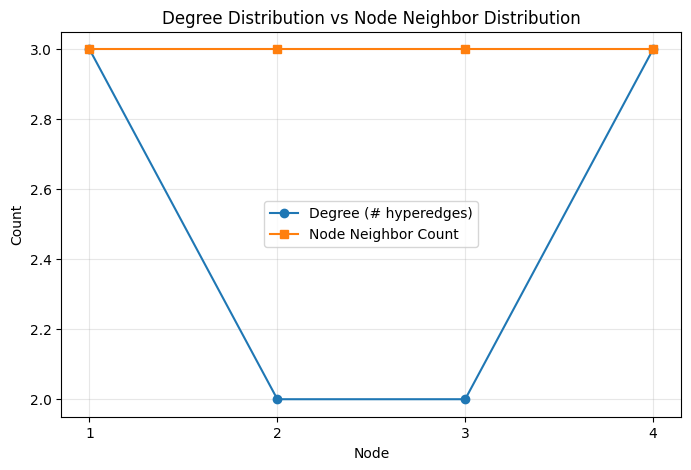

In [142]:

# Compute degree distribution
degree_dict = hypergraph_degree_sequence(J)
degree_values = list(degree_dict.values())

# Compute node-neighbor counts
neighbor_counts = []
for i in range(J.shape[0]):
    neighbors = hypergraph_neighbors(J, i)
    neighbor_counts.append(len(neighbors))

# ---------------------------------------------------
# Plotting
# ---------------------------------------------------
plt.figure(figsize=(8,5))

nodes = np.arange(J.shape[0])

plt.plot(nodes, degree_values, marker='o', label="Degree (# hyperedges)")
plt.plot(nodes, neighbor_counts, marker='s', label="Node Neighbor Count")

plt.xticks(nodes, [n+1 for n in nodes])  # label nodes as 1,2,3,4
plt.xlabel("Node")
plt.ylabel("Count")
plt.title("Degree Distribution vs Node Neighbor Distribution")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

------
Let's look at tool that that can help us with analyzing and handling hypergraphs more effciently:

### Extra Generalized Interactions (xgi)
https://xgi.readthedocs.io/en/stable/

In [105]:
import xgi

Taking our previous list of hyperedges, we can create a hypergraph object and visualize it:

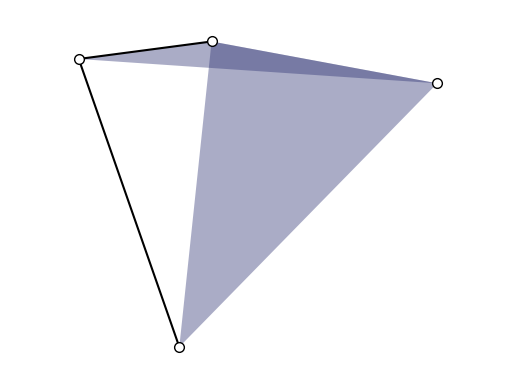

In [250]:
H1 = xgi.Hypergraph(hyperedges)
xgi.draw(H1);

In [251]:
#List the hyperedges
H1.edges.members()

[{0, 1, 2}, {1, 3}, {0, 2, 3}, {0, 3}]

In [252]:
# List the nodes
H1.nodes

NodeView((0, 1, 2, 3))

In [ ]:
# Look at node degrees
H1.nodes.degree.asdict()

{1: 3, 2: 2, 3: 2, 4: 3}

We can also create the hypergraph object using our incidence matrix:

In [53]:
H2 = xgi.Hypergraph(J)
print(f"The hypergraph has {H2.num_nodes} nodes and {H2.num_edges} edges")

The hypergraph has 4 nodes and 4 edges


Now we have functions that can create our incidence or adjacency matrix:

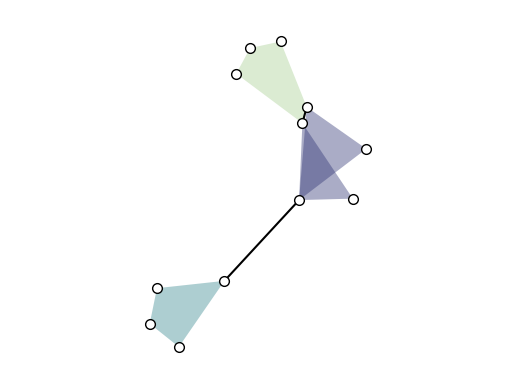

In [ ]:
# Let's create a graph from a new list of hyperedges
H3 = xgi.Hypergraph([[1, 2, 3], [3, 4, 5], [3, 6], [6, 7, 8, 9], [1, 4, 10, 11, 12], [1, 4]])

# Let's visualize our new hypergraph
xgi.draw(H3);

In [96]:
# The incidence matrix
I = xgi.incidence_matrix(H3)
print(I.toarray())

[[1 0 0 0 1 1]
 [1 0 0 0 0 0]
 [1 1 1 0 0 0]
 [0 1 0 0 1 1]
 [0 1 0 0 0 0]
 [0 0 1 1 0 0]
 [0 0 0 1 0 0]
 [0 0 0 1 0 0]
 [0 0 0 1 0 0]
 [0 0 0 0 1 0]
 [0 0 0 0 1 0]
 [0 0 0 0 1 0]]


In [143]:
# The unweighted adjacency matrix 
A_unweighted  = xgi.adjacency_matrix(H3)
print(A_unweighted.toarray())

[[0 1 1 1 0 0 0 0 0 1 1 1]
 [1 0 1 0 0 0 0 0 0 0 0 0]
 [1 1 0 1 1 1 0 0 0 0 0 0]
 [1 0 1 0 1 0 0 0 0 1 1 1]
 [0 0 1 1 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 1 1 1 0 0 0]
 [0 0 0 0 0 1 0 1 1 0 0 0]
 [0 0 0 0 0 1 1 0 1 0 0 0]
 [0 0 0 0 0 1 1 1 0 0 0 0]
 [1 0 0 1 0 0 0 0 0 0 1 1]
 [1 0 0 1 0 0 0 0 0 1 0 1]
 [1 0 0 1 0 0 0 0 0 1 1 0]]


In [ ]:
# The weighted adjacency matrix 
A_weighted = xgi.adjacency_matrix(H3, weighted=True)
print(A_weighted.toarray())

[[0 1 1 2 0 0 0 0 0 1 1 1]
 [1 0 1 0 0 0 0 0 0 0 0 0]
 [1 1 0 1 1 1 0 0 0 0 0 0]
 [2 0 1 0 1 0 0 0 0 1 1 1]
 [0 0 1 1 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 1 1 1 0 0 0]
 [0 0 0 0 0 1 0 1 1 0 0 0]
 [0 0 0 0 0 1 1 0 1 0 0 0]
 [0 0 0 0 0 1 1 1 0 0 0 0]
 [1 0 0 1 0 0 0 0 0 0 1 1]
 [1 0 0 1 0 0 0 0 0 1 0 1]
 [1 0 0 1 0 0 0 0 0 1 1 0]]


Here are functions for the other graph statistics:

In [102]:
df = H3.nodes.multi(["degree", "clustering_coefficient"]).aspandas()
print(df)

    degree  clustering_coefficient
1        3                0.533333
2        1                1.000000
3        3                0.300000
4        3                0.533333
5        1                1.000000
6        2                0.500000
7        1                1.000000
8        1                1.000000
9        1                1.000000
10       1                1.000000
11       1                1.000000
12       1                1.000000


In [103]:
xgi.single_source_shortest_path_length(H3, 1)

{1: 0, 2: 1, 3: 1, 4: 1, 5: 2, 6: 2, 7: 3, 8: 3, 9: 3, 10: 1, 11: 1, 12: 1}

In [104]:
list(xgi.shortest_path_length(H3))[0:3]

[(1,
  {1: 0, 2: 1, 3: 1, 4: 1, 5: 2, 6: 2, 7: 3, 8: 3, 9: 3, 10: 1, 11: 1, 12: 1}),
 (2,
  {1: 1, 2: 0, 3: 1, 4: 2, 5: 2, 6: 2, 7: 3, 8: 3, 9: 3, 10: 2, 11: 2, 12: 2}),
 (3,
  {1: 1, 2: 1, 3: 0, 4: 1, 5: 1, 6: 1, 7: 2, 8: 2, 9: 2, 10: 2, 11: 2, 12: 2})]

------
## 3. Graphs vs. Hypergraphs vs. Simplicial Complexes 

Finding the "right" mathematical object or computational encoding to model a complex system isn't the easiest task. One must consider the domain of the research area, if there are any mechanistic features of the system that govern dynamics, and/or how computationally complex one wants to make the model. The authors of the paper, "The Why, How,and When of Representations for Complex Systems" [21] give an excellent review of this decision making. Below we discuss a new representation, that is, the simplicial complex and go over a few algorithms to map between graphs, hypergraphs, and simplicial complexes. 

*Definition*: A *simplicial complex* is a set nodes $V$ along with a collection of subsets of nodes $K$ such that for any $k \in K$ and $k' \subset k$ we have that $k' \in K$. This condition is known as "downward closure". 

Note that hypergraphs do not need to satisfy the downward closure condition. That is, if $e \in E$ where $E$ is the set of hyperedges, then $e' \subset e $ does not necessarily have to be a hyperedge.

![Figure 9 from Torres et al. (2021)](images/Torres_2021_fig_9.png)

*Figure 9 from Torres, Leo, et al., "The why, how, and when of representations for complex systems," SIAM Review 63(3), 2021.*


### Transforming a hypergraph to a graph

There are many algorithms for transforming a hypergraph into a traditional graph. We name a few below:

#### Hypergraph to Bipartite graph
Given a hypergraph $G = (V, E)$, its incidence bipartite graph $G^{*}$ is constructed
by introducing one new node $v_{e}$ for each hyperedge $e \in E$. Thus the node set of $G^*$ is

$$V^{*} = V \,\cup\, \{ v_{e} : e \in E \}.$$

An edge is placed between a node $v \in V$ and a node $v_{e}$ 
whenever $v$ is incident to $e$ in the hypergraph.  
Hence,

$$E^{*} = \{\, (v, v_{e}) : v \in e,\ e \in E \,\}.$$

The resulting graph $G^{*}$ is bipartite, with parts $V$ and $\{ v_{e} : e \in E \}$, 
and encodes all node incidences of $G$.

Good news -- we've already done the work in employing this algorithm! The graph represented by the hypergraph's incidence matrix is always bipartite. We demonstrate this below:

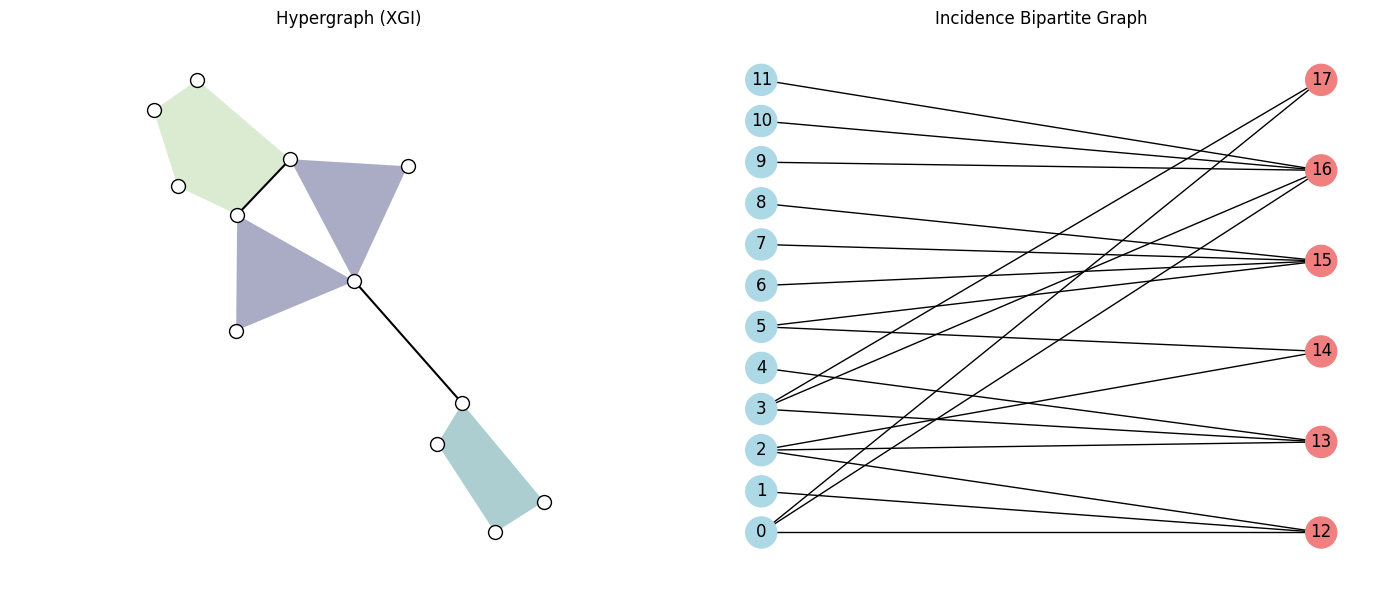

In [204]:
import networkx as nx
import itertools
from itertools import combinations
import matplotlib.pyplot as plt
from networkx.algorithms import bipartite
from scipy.sparse import csr_matrix

# Hypergraph edges
E = [[1, 2, 3], [3, 4, 5], [3, 6], [6, 7, 8, 9], [1, 4, 10, 11, 12], [1, 4]]

HG = xgi.Hypergraph(E)

# Incidence matrix 
J = hypergraph_incidence_matrix(E)   
                     

# Convert to SciPy sparse matrix
B = csr_matrix(J)

G_bip = bipartite.from_biadjacency_matrix(B)





# --- Plot side-by-side: Hypergraph and incidence bipartite graph ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Hypergraph (XGI)
xgi.draw(HG, ax=axes[0], node_size=10)
axes[0].set_title("Hypergraph (XGI)")

# Right: Incidence bipartite graph
pos = nx.bipartite_layout(G_bip, node_partition)  # left part = original nodes
node_colors = [
    "lightblue" if n in node_partition else "lightcoral"
    for n in G_bip.nodes()
]

nx.draw(
    G_bip,
    pos,
    ax=axes[1],
    with_labels=True,
    node_color=node_colors,
    node_size=500,
)
axes[1].set_title("Incidence Bipartite Graph")

plt.tight_layout()
plt.show()


#### Clique Expansion Algorithm 
The clique expansion algorithm [22, 23],  constructs a graph $G^*(V, E^*)$ from the original hypergraph $G(V, E)$ by replacing each hyperedge $e = (v_1, v_2, \cdots, v_{\delta(e)}) \in E$ with an edge for each pair of vertices in the hyperedge. Thus, $E^* = \{(u, v): u, v \in e, e \in E\}$. Note that the vertices in hyperedge $e$ form a clique in the graph $G^*$. 


Good news--We have already performed this algorithm!  The previous unweighted adjacency reflects exactly this new graph, that is, every node in the same hyperedge will have an edge connecting them in $G^*$. The weighted adjacency matrix can be viewed as the weighted clique expansion, where now edge weights between two nodes count the number of hyperedges that contain them both.

Let's take a look at the output of this algorithm using our more complex hypergraph structure from before: 

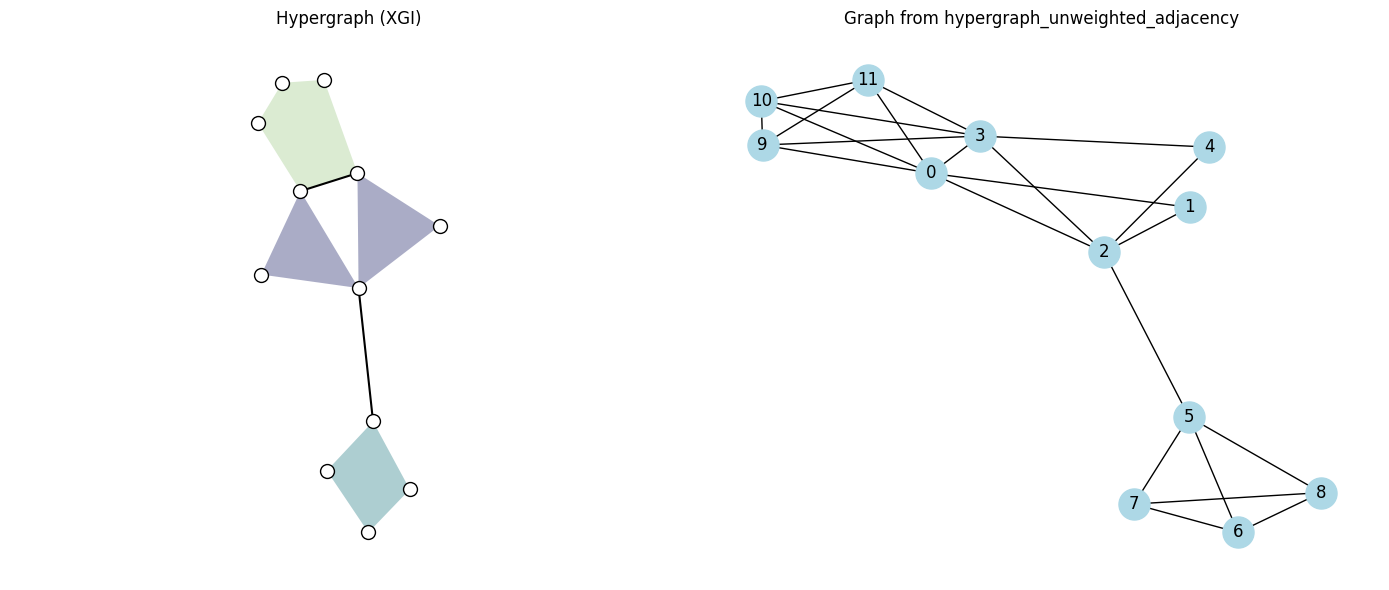

In [ ]:
# Unweighted adjancency / unweighted clique expansion
A = hypergraph_unweighted_adjacency(E)
A = np.asarray(A)

# Determine node labels automatically
n = A.shape[0]
node_labels = list(range(n))  



# Build NetworkX graph
G = nx.from_numpy_array(A)


# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Hypergraph (XGI)
xgi.draw(HG, ax=axes[0], node_size=10)
axes[0].set_title("Hypergraph (XGI)")

# Right: Clique Expansion Graph
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, ax=axes[1],
        with_labels=True,
        node_color="lightblue",
        node_size=500)
axes[1].set_title("Graph from hypergraph_unweighted_adjacency")

plt.tight_layout()
plt.show()


#### Star Expansion Algorithm
The star expansion algorithm [22, 23] constructs a graph $G^* (V^*, E^*)$ from the original hypergraph $G(V, E)$ by introducing a new vertex for every hyperedge $e \in E$, thus $V^* = V \cup E$. It then connects the new graph vertex $e$ to each vertex in the hyperedge. Thus, $E^* = \{ (u, e): u \in e, e \in E\}$ ([22] and [23])

In [182]:


def star_expansion(J):
    """
    Construct the star expansion graph G* of a hypergraph given by its incidence matrix.

    Parameters
    ----------
    J : numpy.ndarray (num_nodes x num_edges)
        Incidence matrix where J[i, j] = 1 if vertex i is in hyperedge e_j.

    Returns
    -------
    A_star : numpy.ndarray (num_nodes_star x num_nodes_star)
        Adjacency matrix of the star-expanded graph G*.
        Indices:
            0 .. num_nodes-1       : original vertices V
            num_nodes .. num_nodes+num_edges-1 : hyperedge-vertices E
    """
    J = np.asarray(J)
    num_nodes, num_edges = J.shape
    num_nodes_star = num_nodes + num_edges

    A_star = np.zeros((num_nodes_star, num_nodes_star), dtype=int)

    # For each incidence J[i, j] = 1, connect node i to hyperedge-vertex (num_nodes + j)
    for i in range(num_nodes):
        # get all hyperedges that contain node i
        incident_edges = np.flatnonzero(J[i, :])
        for j in incident_edges:
            e_vertex = num_nodes + j
            A_star[i, e_vertex] = 1
            A_star[e_vertex, i] = 1  # undirected

    return A_star


Let's visualize the before an after of this algorithm:

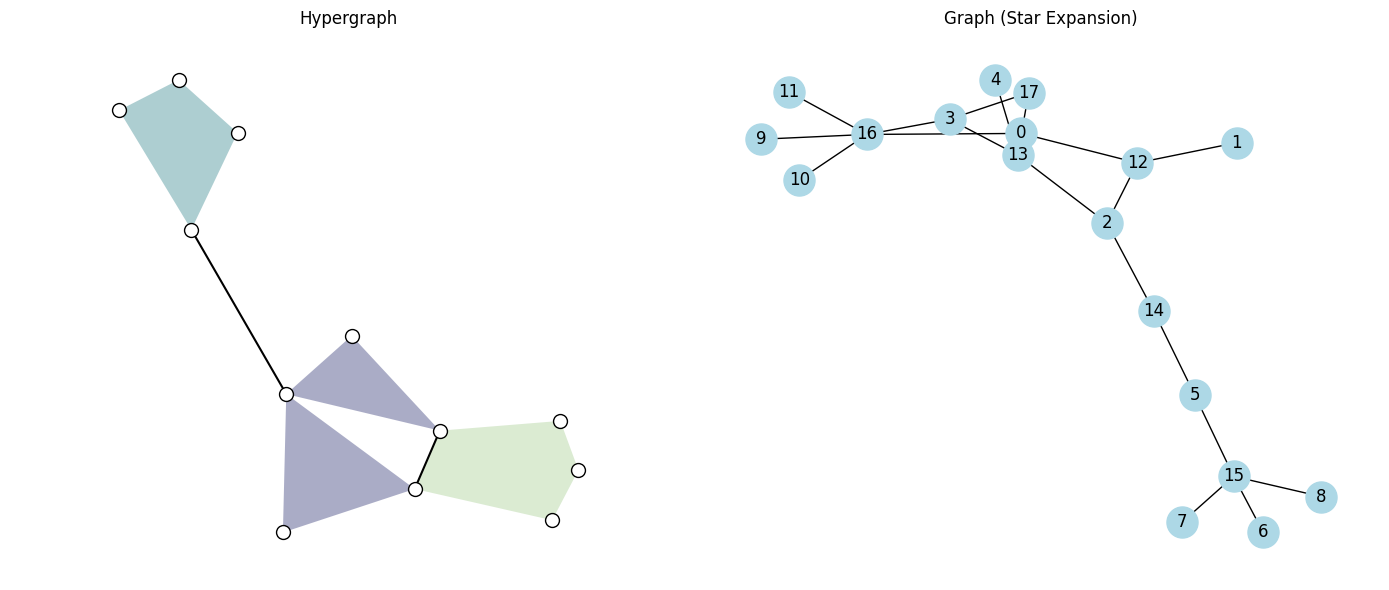

In [185]:


# Create incidence matrix 
I = hypergraph_incidence_matrix(E)
A = star_expansion(I)
A = np.asarray(A)

# Determine node labels automatically
n = A.shape[0]
node_labels = list(range(n))  



# Build NetworkX graph
G = nx.from_numpy_array(A)


# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Hypergraph (XGI)
xgi.draw(HG, ax=axes[0], node_size=10)
axes[0].set_title("Hypergraph")

# Right: Clique Expansion Graph
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, ax=axes[1],
        with_labels=True,
        node_color="lightblue",
        node_size=500)
axes[1].set_title("Graph (Star Expansion)")

plt.tight_layout()
plt.show()

#### Line Graph Expansion Algorithm
Given a hypergraph $G= (V, E)$, the line expansion constructs a graph $G^* = (V^*, E^*)$ whose nodes correspond to the hyperedges of the hypergraph and whose edges connect hyperedges that intersect. Two hyperedges intersect if and only if they share at least one node, so,

$$(e_i, e_j) \in E^* \iff e_i \cap e_j \neq \emptyset$$

Often the line expansion is defined with edge weights, $w(e_i, e_j) = |e_i \cap e_j|$, i.e. the number of shared nodes. This lets you encode how strongly two hyperedges overlap. If $J$ is the $n \times m$ incidence matrix of the hypergraph, the line graph adjacent is:

$$ A_L = J^{\top} J, $$



with diagonal entries set to zero:

$$(A_L)_{ij} = 
\begin{cases}
|e_i \cap e_j|, \hspace{3mm} i \neq j \\
0, \hspace{13mm}  i = j.
\end{cases}
$$

In [194]:

def hypergraph_line_expansion(edges, weighted=True):
    """
    Compute the line expansion (line graph) adjacency matrix of a hypergraph.

    Parameters
    ----------
    edges : list of lists
        Hyperedges, each represented as a list of node indices.
    weighted : bool, default True
        If True, entries (i, j) are the size of the intersection |e_i ∩ e_j|.
        If False, entries are 1 if e_i and e_j intersect, 0 otherwise.

    Returns
    -------
    A_L : numpy.ndarray, shape (m, m)
        Adjacency matrix of the line graph, where m = number of hyperedges.
        Each node in this graph corresponds to a hyperedge of the original
        hypergraph.
    """
    # Build incidence matrix J 
    J = hypergraph_incidence_matrix(edges)   

    # Hyperedge–hyperedge co-occurrence: C = J^T J  (shape m x m)
    C = J.T @ J

    # Remove self-loops (diagonal)
    np.fill_diagonal(C, 0)

    if weighted:
        # Weighted line graph: A_L[i, j] = |e_i ∩ e_j|
        A_L = C
    else:
        # Unweighted: 1 if they intersect, 0 otherwise
        A_L = (C > 0).astype(int)

    return A_L


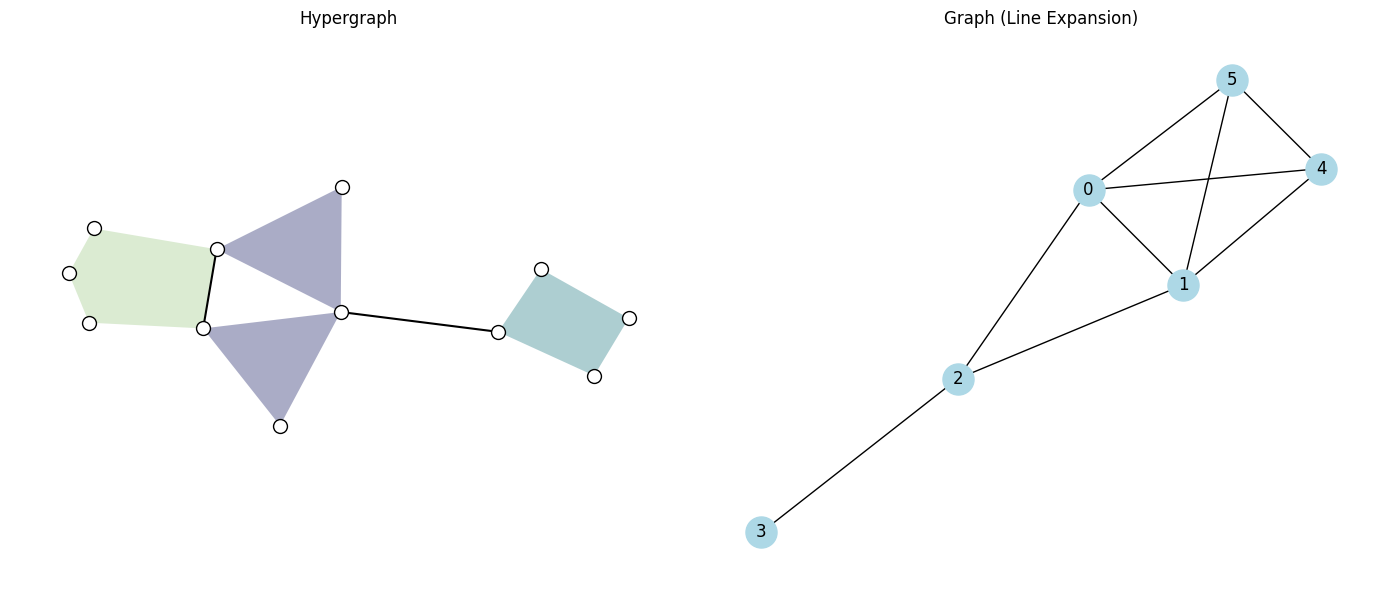

In [198]:

A = hypergraph_line_expansion(E, weighted=True)
#A = np.asarray(A)

# Determine node labels automatically
n = A.shape[0]
node_labels = list(range(n))  



# Build NetworkX graph
G = nx.from_numpy_array(A)


# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Hypergraph (XGI)
xgi.draw(HG, ax=axes[0], node_size=10)
axes[0].set_title("Hypergraph")

# Right: Clique Expansion Graph
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, ax=axes[1],
        with_labels=True,
        node_color="lightblue",
        node_size=500)
axes[1].set_title("Graph (Line Expansion)")

plt.tight_layout()
plt.show()

### Transforming a simplicial complex into a hypergraph
Note: A simplicial complex is already a special kind of hypergraph where each simplex is a subset of vetices which is a hyperedge. We can construct a hypergraph from a simplicial complex by looking at subset of the simplexes. The algorithm below constructs a hypergraph using only the maximal simplices of the simplicial complex. 

 *Recall*: A simplicial complex is a collection $K = \{\sigma_1, \sigma_2, \cdots \sigma_m\}$, where each $\sigma_i$ is a simplex (a finte set of nodes).

*Definition*: A simplex $\sigma \in K$ is maximal if no other simplex  $\tau \in K$ strictly contains it. That is, $\sigma \subsetneq \tau$.

 To construct a hypergraph $G = (V, E)$ from a simplicial complex, first map the nodes $K$ to be the nodes of $G$ so that $V = \bigcup_{\sigma \in K} \sigma$. Then, set the hyperedges to be the set of all maxmal simplices: 



$$E = \{ \sigma \in K: \sigma  \text{ is maximal}\}$$

In [244]:
def simplicial_complex_to_HG(K):
    # K = list of simplices
    simplices = [set(s) for s in K]

    # Obtain vertices
    V = sorted(set().union(*simplices))

    # Find maximal simplices
    maximal = []
    for s in simplices:
        if not any((s < t) for t in simplices):  # strict subset test
            maximal.append(s)

    # Obtain hyperedges
    E = [sorted(list(s)) for s in maximal]

    return V, E


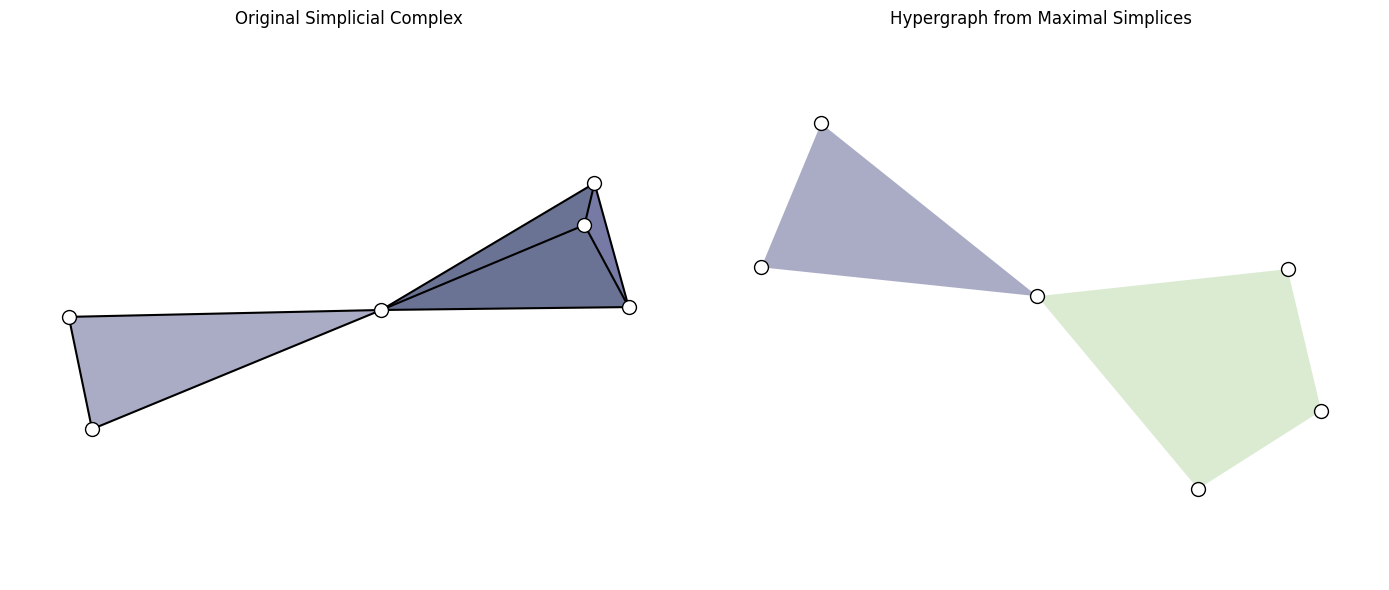

In [ ]:


# Helper function: expand to full simplicial complex (all faces)
def closure_under_faces(K_maximal):
    """
    Given maximal simplices, returns ALL faces of each simplex.
    """
    faces = set()
    for simplex in K_maximal:
        simplex = list(simplex)
        for r in range(1, len(simplex) + 1):
            for comb in itertools.combinations(simplex, r):
                faces.add(tuple(sorted(comb)))

    K_full = [list(f) for f in sorted(faces, key=lambda x: (len(x), x))]
    return K_full


# Example simplicial complex
K = [
    [0, 1, 2],      
    [2, 3, 4, 5]   
]

# New hypergraph
V, E = simplicial_complex_to_HG(K)

# Build full simplicial complex (with all faces) for visualization
K_full = closure_under_faces(K)

# Build XGI hypergraphs for plotting
HG_complex = xgi.Hypergraph(K_full)    # all faces
HG_maximal = xgi.Hypergraph(E)         # only maximal simplices



# Plot 

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: full simplicial complex
xgi.draw(HG_complex, ax=axes[0], node_size=10)
axes[0].set_title("Original Simplicial Complex")

# Right: hypergraph after algorithm (only maximal simplices)
xgi.draw(HG_maximal, ax=axes[1], node_size=10)
axes[1].set_title("Hypergraph from Maximal Simplices")

plt.tight_layout()
plt.show()




*Discussion*: Describe an algorithm that takes a hypergraph and transforms it into a simplicial complex. Do the same for a simplicial complex to a graph. 

________
## 4. Hypergraph Models

Generating hypergraph structures from data has become an area of increasing interest within the network science community. Many real-world systems—such as social, biological, and technological networks—exhibit higher-order correlations that cannot be adequately captured by pairwise interactions alone. Because these systems are often large-scale, involving millions or even billions of nodes, they can be analytically and computationally intractable. Hypergraph models offer a powerful way to encode and analyze these multiway relationships, making them indispensable for studying complex systems with high-order dynamics.

Dai and Gao [2], give a systematic review in chapter 4 of their book "Hypergraph Computation." Below we provide a brief summary of the two major methods for modeling hypergraphs. 

![Figure 4.1 from Dai and Gao (2023)](images/Dai_and_Gao_2023_fig_4.1.png)

*Figure 4.1  from Dai and Gao (2023), "Hypergraph computation." Springer Nature, 2023.*

*Definition*: Implicit hypergraph modeling constructs the hypergraph structure from node representations. This is typically done via their distances or similarity measures. Therefore, the relationships among vertices are not explicitly given but instead inferred.

*Definition*: Explicit hypergraph modeling, uses known correlations or attributes in the data to directly specify the structure of the hypergraph.

### Implicit Hypergraph Modeling
* Distance-Based Hypergraph Generation - Constructs the hyperedges of the hypergraph by grouping nodes that are close to one another in the feature space. An example of this is the "k-NN nearest-neighbor model." 

##### k-NN Nearest-Neighbor in Hypergraph Construction
Given a target node $v$, k-NN finds the set:
$$\mathcal{N}_k(v) = \{\text{the $k$ closest points to v}\}$$

where closeness is measured by a chosen metric (i.e. Euclidean distance). A hyperedge is the target node and all of its nearest neighbors. That is, a hyperedge is created containing $\{v \cup \mathcal{N}_k(v)\}$. This is repeated for every node in the feature space.



In [ ]:
# Distance-Based Hypergraph Generation 

def knn_hypergraph(X, k):
    """
    Construct a k-NN hypergraph from data.

    For each point i, we find its k nearest neighbors
    (excluding itself) and create one hyperedge:
        e_i = { i } ∪ N_k(i)

    Parameters
    ----------
    X : numpy.ndarray, shape (n_samples, n_features)
        Data matrix where each row is a data point.
    k : int
        Number of nearest neighbors for each centroid.
    return_incidence : bool, default True
        If True, also return the incidence matrix J (n_samples x num_hyperedges).

    Returns
    -------
    edges : list of lists
        List of hyperedges. Each hyperedge is a sorted list of node indices.
    J : numpy.ndarray, optional
        Incidence matrix of shape (n_samples, num_hyperedges),
        where J[i, j] = 1 if node i is in hyperedge j, 0 otherwise.
        Only returned if return_incidence=True.
    """

    X = np.asarray(X)
    n_samples = X.shape[0]

    if k >= n_samples:
        raise ValueError("k must be less than the number of samples.")

    #  Compute pairwise distance matrix (Euclidean) -
    # D[i, j] = distance between X[i] and X[j]
    diff = X[:, None, :] - X[None, :, :]      
    D = np.linalg.norm(diff, axis=2)           

    # Avoid self as neighbor by setting diagonal to +inf
    np.fill_diagonal(D, np.inf)

    # For each point, find its k nearest neighbors and form hyperedges 
    raw_edges = []
    for i in range(n_samples):
        # Indices of k nearest neighbors of i
        nn_idx = np.argsort(D[i])[:k]          
        # Hyperedge contains centroid i plus its neighbors
        edge = [i] + nn_idx.tolist()
        edge_sorted = tuple(sorted(edge))     
        raw_edges.append(edge_sorted)

    # Deduplicate hyperedges (different centroids can yield same set) ---
    edge_set = sorted(set(raw_edges))          # list of unique tuples
    edges = [list(e) for e in edge_set]


    return edges



Random 2D points X:
 [[0.26910342 0.2250845 ]
 [0.50844427 0.38266472]
 [0.35473662 0.67734795]
 [0.03940427 0.52930674]
 [0.87050069 0.76149098]
 [0.10206432 0.01554908]
 [0.25640822 0.98067733]
 [0.13244806 0.45550761]
 [0.64052271 0.92289151]
 [0.14134152 0.85483593]] 

Hyperedges:
[0, 1, 2, 7]
[0, 1, 5, 7]
[0, 2, 3, 7]
[0, 3, 5, 7]
[1, 2, 4, 8]
[2, 3, 6, 9]
[2, 3, 7, 9]
[2, 4, 6, 8]
[2, 6, 7, 9]
[2, 6, 8, 9]


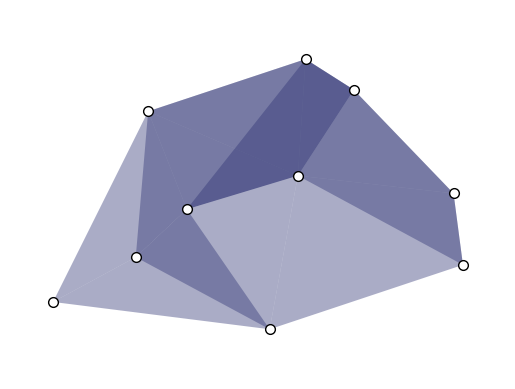

In [216]:
X = np.random.rand(10, 2)   # Generate 10 random points in 2D
k = 3
edges =  knn_hypergraph(X, k)

H = xgi.Hypergraph(edges)

print("Random 2D points X:\n", X, "\n")

print("Hyperedges:")
for e in edges:
    print(e)

xgi.draw(H);



* Representation-Based Hypergraph Generation
In contrast to distance-based techniques, which build hyperedges by measuring similarities in feature space, representation-based techniques infer relationships among vertices by examining how well each vertex’s features can be reconstructed. An illustration of this is provided by Dai and Gao [2]:


An example of a representation-based hypergraph algorithm is the $\ell_1$-hypergraph model:

#### $\ell_1$-hypergraph model

In the $\ell_1$-hypergraph construction, sparse representation is used to define the relationship between a hyperedge and its vertices. The idea is that the centroid vertex of a hyperedge is reconstructed as a sparse linear combination of the other vertices in that hyperedge. The resulting reconstruction coefficients then serve as entries of the hypergraph’s incidence matrix.

Formally, let $v_c$ be the centroid vertex. Its feature vector $X(v_c)$​ is approximated using the feature matrix $B$ of its $k$ nearest neighbors. The reconstruction coefficients $z$ are obtained by solving

$$\arg\min_{z} \|Bz - X(v_c)\|_2^2 + \gamma \|z\|_1$$

where $z_i$ indicates how much the $i$-th neighbor contributes to reconstructing $v_c$ and $\gamma$ is a hyperparameter that balances the infleunces of the two terms. Larger coefficients correspond to stronger connections in the resulting hyperedge. 

In [ ]:
from sklearn.linear_model import Lasso


def l1_hypergraph(X, k, gamma=0.1, coef_tol=1e-6):
    """
    Construct an ℓ1-hypergraph from feature data via sparse reconstruction.

    For each node v_c:
      1. Find its k nearest neighbors in feature space.
      2. Solve:  min_z ||B z - X[v_c]||_2^2 + gamma * ||z||_1
         s.t. z_i >= 0  (nonnegative sparse representation)
      3. Use the nonzero coefficients to define a hyperedge whose centroid is v_c.
         That is, v_c is in the hyperedge, along with neighbors whose coeff > coef_tol.

    Parameters
    ----------
    X : np.ndarray, shape (n_nodes, n_features)
        Feature matrix; row i is the feature vector of node i.
    k : int, default=5
        Number of nearest neighbors used to form candidate basis vectors.
    gamma : float, default=0.1
        Sparsity regularization parameter (L1 penalty weight).
    coef_tol : float, default=1e-6
        Threshold below which coefficients are treated as zero.

    Returns
    -------
    H : np.ndarray, shape (n_nodes, n_nodes)
        Incidence matrix of the ℓ1-hypergraph.
    """

    n_nodes, n_features = X.shape

    # Precompute pairwise distances for k-NN
    diff = X[:, np.newaxis, :] - X[np.newaxis, :, :]
    dist = np.linalg.norm(diff, axis=2)

    # For self-distance, set to +inf so it's never chosen as a neighbor
    np.fill_diagonal(dist, np.inf)

    H = np.zeros((n_nodes, n_nodes), dtype=int)
    coeffs = []
    neighbor_indices = []

    # For each node as centroid v_c
    for c in range(n_nodes):
        # Find k nearest neighbors of node c ---
        nbr_idx = np.argsort(dist[c])[:k]  
        neighbor_indices.append(nbr_idx)

        # Feature vector of centroid
        x_c = X[c]  

        # Basis matrix B: columns are neighbor feature vectors
        B = X[nbr_idx].T

        # Solve the sparse reconstruction problem 
        lasso = Lasso(alpha=gamma, fit_intercept=False, positive=True, max_iter=5000)
        lasso.fit(B, x_c)

        z = lasso.coef_ 
        coeffs.append(z)

        # Build hyperedge for centroid c 
        active_mask = z > coef_tol
        active_neighbors = nbr_idx[active_mask]

        # Always include the centroid itself
        H[c, c] = 1
        H[active_neighbors, c] = 1

    return H


Feature matrix X:
[[ 0.09019311  2.60012772]
 [-0.65065436 -1.20636009]
 [ 2.08582016 -2.1102786 ]
 [-0.47408581  0.91225939]
 [ 1.84844902 -0.13964047]
 [-0.90908201 -1.09599581]
 [-1.52518183  0.46649291]
 [ 1.64398608  1.18717456]
 [-0.35112929  1.65960569]
 [-1.50181243  1.70480198]]

Incidence matrix H:
[[1 0 0 0 0 0 0 1 1 0]
 [0 1 1 0 0 1 0 0 0 0]
 [0 0 1 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0]
 [0 0 1 0 1 0 0 1 0 0]
 [0 1 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 1 1 0 0 1]
 [0 0 0 0 1 0 0 1 0 0]
 [1 0 0 1 0 0 0 0 1 1]
 [0 0 0 1 0 0 1 0 1 1]]


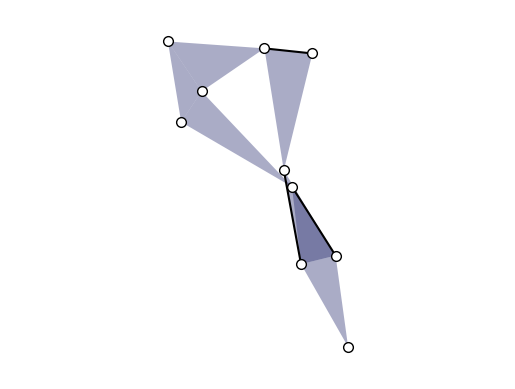

In [223]:


# Create toy data
X = np.random.randn(10, 2)

# Build the l1-hypergraph
I = l1_hypergraph(X, k=3, gamma=0.1, coef_tol=1e-4)
H = xgi.Hypergraph(I)

print("Feature matrix X:")
print(X)

print("\nIncidence matrix H:")
print(I)



xgi.draw(H);


### Explicit Hypergraph Modeling

Sometimes there are known existing connections within a dataset. Explicit hypergraph modeling involves generating hypergraph structures using attribution information in networks. 

* Attribute-Based Hypergraph Generation - To construct an attribute-based hypergraph, two main steps are required:
    (1) building the node and hyperedge sets, and
    (2) assigning weights to the hyperedges to form the weight matrix $W$.
First, each data sample is represented as a node in the node set $V$ Attributes shared among samples signal common characteristics—such as labels, categories, or subjective evaluations. Thus, each attribute naturally defines a hyperedge: all nodes possessing the same attribute are connected by that hyperedge. Formally, for each attribute $a \in \mathcal{A}$ we create a hyperedge

$$ E_{attribute} = \{N_{att}(a) | a \in \mathcal{A}\},$$

where $N_{att}(a)$ is the subset of nodes in $V$ that share attribute $a$. Consequently, the number of hyperedges equals the number of attributes. 


* Network-Based Hypergraph Generation - This methof starts with a traditional graph G=(V,E) and transform its pairwise connections into higher-order relations. The goal is to reveal or model group-level interactions by inferring it from its topology. These methods generally follow two steps:
    (1) Identify higher-order structures in the graph. These structures (such as cliques, communities, or motifs) capture multi-node relationships that go beyond pairwise edges.
    (2) Convert these structures into hyperedges. Each detected structure becomes a hyperedge connecting all participating vertices. 


Below we provide an example of Network Based Hypergraph Generation called the "$k$-Hop-Based Hyperedge Generation Model:"

##### $k$-Hop-Based Hyperedge Generation Model
Let $G_s = (V_s, E_s)$ be the input graph, where each node $v_i \in V_s$ and each edge $e_{ij}^s \in E_s$ connects $v_i$ and $v_j$. The adjancency matrix of $G_s$ is denoted by $A$. In the $k$-hop model, hyperedges are formed using $k$-hop neighborhoods of each node. The $k$-hop neighborhood of a node $v$ is defined as 

$$N_{k}^{hop}(v) = \{u | A_{uv}^k \neq 0 , u \in V_s\}, $$

that is, all nodes reachable from $v$ in exactly $k$ steps. Here, $k$ ranges from $2$ to the number of nodes in the graph. 

A hyperedge group generated by this method is 

$$E_k ^{hop} = \{N_{k}^{hop}(v)| v\in V_s\}.$$

In [225]:

def k_hop_hypergraph(A, k, include_center=False):
    """
    Construct k-hop hyperedges from a graph adjacency matrix.
    
    For each vertex v, compute its k-hop neighborhood using A^k and treat
    that neighborhood as a hyperedge.

    Parameters
    ----------
    A : numpy.ndarray, shape (n, n)
        Adjacency matrix of the graph.
    k : int
        Number of hops.
    include_center : bool, default False
        Whether to include the central vertex v if reachable via a k-hop cycle.
    drop_empty : bool, default True
        If True, remove hyperedges that have no vertices.

    Returns
    -------
     H : np.ndarray
        Incidence matrix of the k-hop-hypergraph.
    """


    n = A.shape[0]

    # Compute A^k
    Ak = np.linalg.matrix_power(A, k)

    hyperedges = []


    for v in range(n):
        neighbors = np.flatnonzero(Ak[:, v] != 0).tolist()

        if not include_center:
            neighbors = [u for u in neighbors if u != v]

        # Always drop empty hyperedges
        if neighbors:
            hyperedges.append(sorted(neighbors))

    # Compute incidence matrix of hypergraph
    H = hypergraph_incidence_matrix(hyperedges)


    return H


Adjacency Matrix A (Karate Club):
[[0 4 5 ... 2 0 0]
 [4 0 6 ... 0 0 0]
 [5 6 0 ... 0 2 0]
 ...
 [2 0 0 ... 0 4 4]
 [0 0 2 ... 4 0 5]
 [0 0 0 ... 4 5 0]]

10-hop Hypergraph Incidence Matrix H:
[[1 0 1 ... 1 1 1]
 [1 1 0 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 0 1 1]
 [1 1 1 ... 1 0 1]
 [1 1 1 ... 1 1 1]]


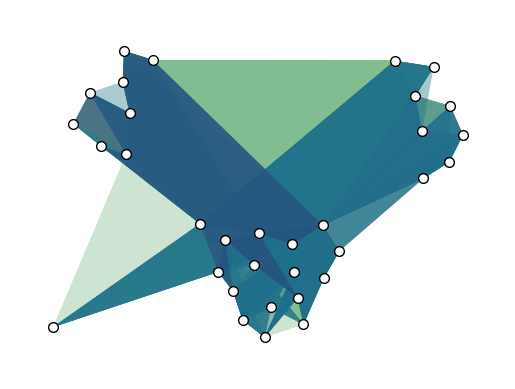

In [228]:
# Example with using karate club graph 
G = nx.karate_club_graph()
A = nx.to_numpy_array(G, dtype=int)

# Choose k-hop
k = 3

# Build the hypergraph incidence matrix
H = k_hop_hypergraph(A, k)

H_xgi = xgi.Hypergraph(H) 


print("Adjacency Matrix A (Karate Club):")
print(A)

print("\n10-hop Hypergraph Incidence Matrix H:")
print(H)

xgi.draw(H_xgi);


### Random Hypergraph Models
Random hypergraph models generalize classical random graph models to settings where interactions involve more than two nodes. 


Your turn! Build an Erdős–Rényi Random Hypergraph. That is, fix $n$ nodes and choose each possible $k$-node hyperedge independently with probability $p$. Return the set of hyperedges. Use xgi to draw an example with your choice of $n, k \text{ and } p.$



In [ ]:
# Your turn!
def Erdos_Renyi_HG_model(n, k, p):
    pass

In [229]:
#Solution: 

import random
from itertools import combinations

def erdos_renyi_hypergraph(n, k, p, seed=None):
    """
    Generate a k-uniform Erdős–Rényi random hypergraph H^k(n, p).

    Parameters
    ----------
    n : int
        Number of vertices, labeled 0, 1, ..., n-1.
    k : int
        Size of each hyperedge (uniform hypergraph).
    p : float
        Probability that any given k-subset of vertices is included as a hyperedge.
    seed : int, optional
        Random seed.

    Returns
    -------
    edges : list of tuples
        List of k-tuples representing hyperedges.
    """
    if seed is not None:
        random.seed(seed)

    if k > n:
        raise ValueError("k cannot be greater than n.")

    edges = []
    for combo in combinations(range(n), k):
        if random.random() < p:
            edges.append(combo)

    return edges


Let's plot a range of probabilities: 

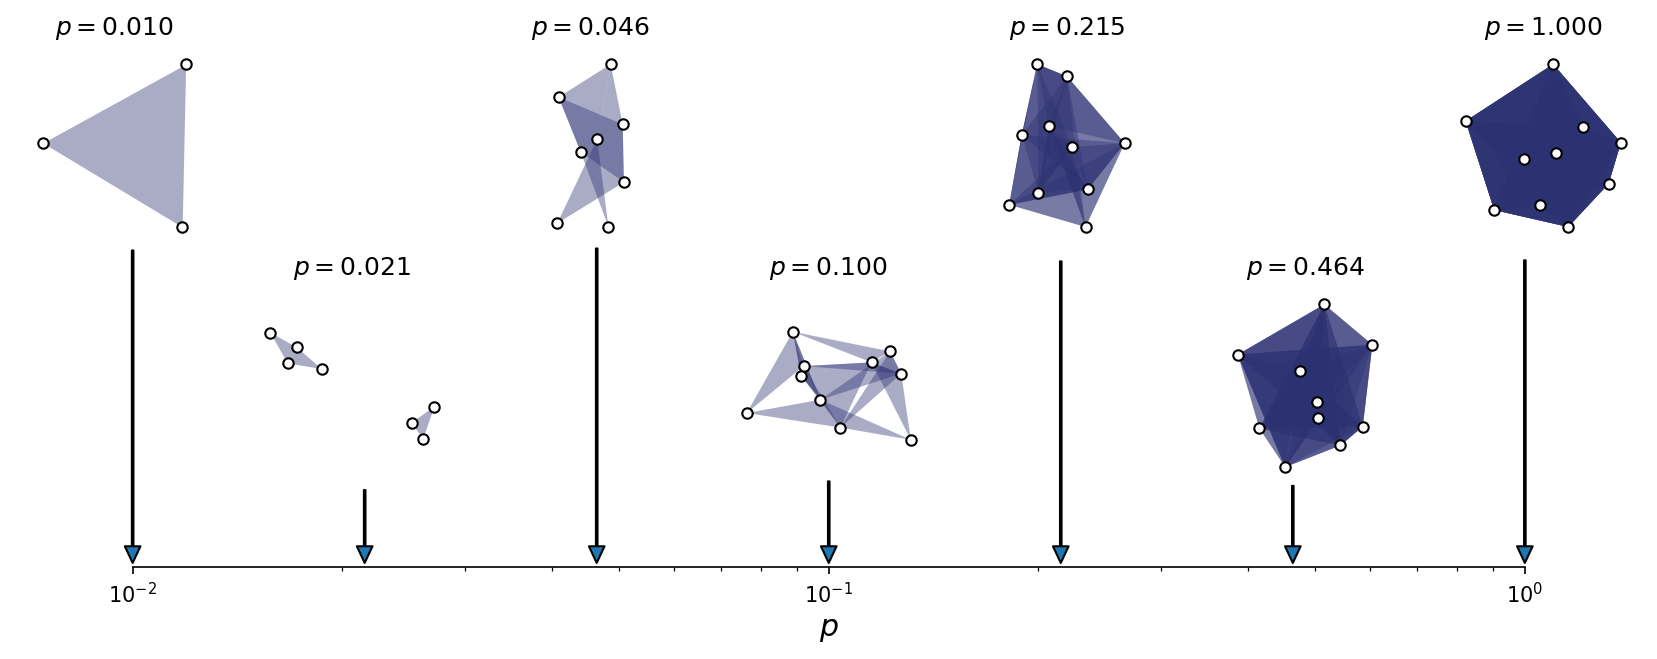

In [234]:



# Plot setup
w = 2.0; h = 2.0
ncols = 7; nrows = 3

tups = list(itertools.product(range(nrows), range(ncols)))

plot_tups = [i for i in tups[::2] if i[0] < (nrows-1)]
plot_tups = sorted(plot_tups, key=lambda x: x[1])

fig, ax = plt.subplots(
    nrows, ncols, figsize=(14, 4.5), dpi=150,
    gridspec_kw={'height_ratios':[1.0, 1.0, 0.2]}
)

plt.subplots_adjust(wspace=0.2, hspace=0.3)
gs = fig.add_gridspec(nrows, ncols*2, height_ratios=[1,1,0.2])

axi0 = fig.add_subplot(gs[(nrows-1), 1:(ncols*2-1)])
axi0.set_xscale('log')
axi0.set_yticks([])
axi0.spines['top'].set_visible(False)
axi0.spines['right'].set_visible(False)
axi0.spines['left'].set_visible(False)
axi0.set_xlabel(r'$p$', fontsize='x-large')

# Hypergraph plotting with XGI 
N = 10      
k = 3        
params = np.logspace(-2, 0, 7).round(4)

for i, a in enumerate(plot_tups):
    axi = ax[a]
    p = params[i]

    # Generate hypergraph and convert to XGI object
    edges = erdos_renyi_hypergraph(N, k, p, seed=i)
    H = xgi.Hypergraph(edges)

    # Draw hypergraph 
    xgi.draw(H, ax=axi, node_size=5)

    axi.set_axis_off()
    axi.set_title(r"$p=%0.3f$" % p)

    # Arrow annotation
    net_x = a[1] / (ncols - 1)

    net_y = 7.75 if a[0] == 0 else 1.75
    net_y += np.random.rand() * 0.5
    axi0.annotate(
        '',
        xy=(net_x, 0.1),
        xytext=(net_x, net_y),
        xycoords='axes fraction',
        textcoords='axes fraction',
        arrowprops=dict(width=0.75, headwidth=7.5, headlength=8)
    )

axi0.set_xlim(1e-2, 1e0)
axi0.set_ylim(0, 1)

# Turn off unused subplots
for a in tups:
    if a in plot_tups:
        continue
    ax[a].set_axis_off()

plt.show()


### If time ....Real data example
A collaboration network is loaded as an adjacency matrix $A$ below. 
1.  Use $A$ to construct: 
    * (a) A k-NN hypergraph using the knn_hypergraph function. Build a simple feature matrix $X$ where each row corresponds to a node and contains a basic structural feature (e.g., node degree ). Used an induced subgraph with at most 2000 nodes.
    * (b) A clique-based hypergraph using the simplicial_complex_to_HG function. Build the simplicial complex by finding maximal cliques on an induced subgraph with at most 2000 nodes.
2. Give summary statistics of each hypergraph (i.e. number of nodes, number of hyperedges, min/avg/max hyperedge size etc.)
3. Discuss what both hypergraphs means in the context of mathematical collaboration

In [239]:
import scipy.io
import scipy.sparse as sp

data = scipy.io.mmread("data/ca-MathSciNet.mtx")

A = data.tocsr()
A= ((A + A.T) > 0).astype(int) # Symmetrize just in case (co-authorship is undirected)
A.setdiag(0)# Remove self-loops
A.eliminate_zeros()
    
  

In [241]:
### Solution ###


 # Convert to NetworkX graph
G = nx.from_scipy_sparse_array(A)

# For both hypergraph constructions, we'll work on the same subgraph to keep things computationally tractable.
max_nodes = 2000
nodes_sub = list(G.nodes())[:max_nodes]
G_sub = G.subgraph(nodes_sub).copy()



#Step 1(a)

def build_feature_matrix_from_graph(G_sub, nodes_sub):
    """
    Build a feature matrix X with two features per node:
      - degree
      - clustering coefficient

    Parameters
    ----------
    G_sub : networkx.Graph
        Induced subgraph.
    nodes_sub : list
        List of node labels (global ids) to use, in the order
        that rows of X should correspond to.

    Returns
    -------
    X : numpy.ndarray of shape (m, 2)
        Feature matrix.
    """
    # Degree (as dict: node -> deg)
    deg_dict = dict(G_sub.degree())

    # Clustering coefficient (node -> cc)
    cc_dict = nx.clustering(G_sub)

    # Build X in the order of nodes_sub
    X = np.zeros((len(nodes_sub), 2), dtype=float)
    for i, v in enumerate(nodes_sub):
        X[i, 0] = deg_dict.get(v, 0.0)
        X[i, 1] = cc_dict.get(v, 0.0)

    return X

X = build_feature_matrix_from_graph(G_sub, nodes_sub)
k_nn = 10  # you can choose any k
H_knn_local = knn_hypergraph(X, k=k_nn)


# Map local indices back to global node labels for interpretability
H_knn_global = []
for he in H_knn_local:
    he_global = [nodes_sub[i] for i in he]
    H_knn_global.append(he_global)


In [246]:
### Solution ###

#Step 1(b)
# Find maximal cliques in the subgraph
cliques = list(nx.find_cliques(G_sub))

# Treat the set of cliques as a simplicial complex K
K = cliques

V_clique, H_clique_edges = simplicial_complex_to_HG(K)


In [247]:
### Solution ###

 #Step 2
def summarize_hypergraph(edges, num_nodes=None, name="Hypergraph"):
    """
    Print a few simple summary statistics for a hypergraph given as a list of edges (hyperedges),
    where each hyperedge is an iterable of node indices.
    """
    if num_nodes is None:
        # Infer from edges
        if not edges:
            num_nodes = 0
        else:
            num_nodes = 1 + max(max(e) for e in edges)

    num_edges = len(edges)
    if num_edges > 0:
        sizes = [len(e) for e in edges]
        avg_size = float(np.mean(sizes))
        max_size = max(sizes)
        min_size = min(sizes)
    else:
        avg_size = max_size = min_size = 0

    print(f"=== {name} ===")
    print(f"Number of nodes:       {num_nodes}")
    print(f"Number of hyperedges:  {num_edges}")
    print(f"Hyperedge size (min):  {min_size}")
    print(f"Hyperedge size (avg):  {avg_size:.2f}")
    print(f"Hyperedge size (max):  {max_size}")
    print()


summarize_hypergraph(H_knn_global, name=f"k-NN hypergraph (k={k_nn}, structural features)")

summarize_hypergraph(H_clique_edges, num_nodes=len(V_clique), name="Clique-based hypergraph (on subgraph)")

=== k-NN hypergraph (k=10, structural features) ===
Number of nodes:       2000
Number of hyperedges:  1958
Hyperedge size (min):  11
Hyperedge size (avg):  11.00
Hyperedge size (max):  11

=== Clique-based hypergraph (on subgraph) ===
Number of nodes:       2000
Number of hyperedges:  1818
Hyperedge size (min):  1
Hyperedge size (avg):  1.19
Hyperedge size (max):  4



________
## Today, we didn't cover: 
* Centrality Measures for Hypergraphs
* Community detection using spectral theory on hypergraphs
* Higher-order Dynamics 
* Random Walks on Hypergraphs


# Sources 
1. Bretto, Alain. "Hypergraph theory." An introduction. Mathematical Engineering. Cham: Springer 1 (2013): 209-216.
2. Dai, Qionghai, and Yue Gao. Hypergraph computation. Springer Nature, 2023.
3. Ouvrard, Xavier. "Hypergraphs: an introduction and review." arXiv preprint arXiv:2002.05014 (2020).
4. Pickard, Joshua, et al. "HAT: Hypergraph analysis toolbox." PLOS Computational Biology 19.6 (2023): e1011190.
5. López, Eduardo. "The distribution of the number of node neighbors in random hypergraphs." Journal of Physics A: Mathematical and Theoretical 46.30 (2013): 305003.
6. Liu, Qingshan, et al. "Elastic net hypergraph learning for image clustering and semi-supervised classification." IEEE Transactions on Image Processing 26.1 (2016): 452-463.
7. Wang, Meng, Xueliang Liu, and Xindong Wu. "Visual classification by $\ell _1 $-hypergraph modeling." IEEE Transactions on Knowledge and Data Engineering 27.9 (2015): 2564-2574.
8. Wang, Jian-Wei, et al. "Evolving hypernetwork model." The European Physical Journal B 77.4 (2010): 493-498.
9. Lung, Rodica Ioana, Noémi Gaskó, and Mihai Alexandru Suciu. "A hypergraph model for representing scientific output." Scientometrics 117.3 (2018): 1361-1379.
10. Inoue, Masaaki, Thong Pham, and Hidetoshi Shimodaira. "A hypergraph approach for estimating growth mechanisms of complex networks." IEEE Access 10 (2022): 35012-35025.
11. Iacopini, Iacopo, et al. "Simplicial models of social contagion." Nature communications 10.1 (2019): 2485.
12. Pearcy, Nicole, Jonathan J. Crofts, and Nadia Chuzhanova. "Hypergraph models of metabolism." International Journal of Biological, Veterinary, Agricultural and Food Engineering 8.8 (2014): 752-756.
13. Ramadan, Emad, Arijit Tarafdar, and Alex Pothen. "A hypergraph model for the yeast protein complex network." 18th International Parallel and Distributed Processing Symposium, 2004. Proceedings.. IEEE, 2004.
14. Feng, Song, et al. "Hypergraph models of biological networks to identify genes critical to pathogenic viral response." BMC bioinformatics 22.1 (2021): 287.
15. Zhang, Zi-Ke, and Chuang Liu. "A hypergraph model of social tagging networks." Journal of Statistical Mechanics: Theory and Experiment 2010.10 (2010): P10005.
16. Estrada, Ernesto, and Juan A. Rodriguez-Velazquez. "Complex networks as hypergraphs." arXiv preprint physics/0505137 (2005).
17. Lotito, Quintino Francesco, et al. "Higher-order motif analysis in hypergraphs." Communications Physics 5.1 (2022): 79.
18. Estrada, Ernesto, and Juan A. Rodríguez-Velázquez. "Subgraph centrality and clustering in complex hyper-networks." Physica A: Statistical Mechanics and its Applications 364 (2006): 581-594.
19. Benson, Austin R. "Three hypergraph eigenvector centralities." SIAM Journal on Mathematics of Data Science 1.2 (2019): 293-312.
20. Lung, Rodica Ioana, Noémi Gaskó, and Mihai Alexandru Suciu. "A hypergraph model for representing scientific output." Scientometrics 117.3 (2018): 1361-1379.
21. Torres, Leo, et al. "The why, how, and when of representations for complex systems." SIAM Review 63.3 (2021): 435-485.
22. Agarwal, Sameer, Kristin Branson, and Serge Belongie. "Higher order learning with graphs." Proceedings of the 23rd international conference on Machine learning. 2006.
23. Zien, J. Y., Schlag, M. D. F., & Chan, P. K. (1999). Multilevel spectral hypergraph partitioning with arbitrary vertex sizes. IEEE Transactions on Computer-Aided Design
of Integrated Circuits and Systems, 18, 1389–1399.


